# Exoplanet Data Analysis Similarity Search

In [254]:
# general importing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# K-Nearest Neighbor importing
from sklearn.impute import KNNImputer
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
# regex importing for pattern recognition
import re

In [233]:
# loading dataset
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/exoplanet_filtered_dataset_removed_outliers_analysis.xlsx')

In [234]:
df.head()

,planet_name,host_star_name,spectral_type,stellar_effective_temp_k,planet_equil_temp_k,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,stellar_rad_solar_rad,stellar_mass_solar_mass,distance_parsec,Eccentricity,stellar_surf_grav,declination_deg,discovery_method
0,11 Com b,11 Com,G8 III,4808.000,NaN,324.620000,1.226000,NaN,5505.066163,16.380000,2.463333,93.1846,0.234500,2.380,17.793252,Radial Velocity
1,11 UMi b,11 UMi,K4 III,4276.500,NaN,516.219985,1.526667,NaN,3818.094733,26.935000,2.093333,125.3210,0.080000,1.765,71.823943,Radial Velocity
2,14 And b,14 And,K0 III,4850.500,NaN,186.300000,0.761667,NaN,1224.550433,11.275000,1.726667,75.4392,0.000000,2.590,39.235837,Radial Velocity
3,14 Her b,14 Her,K0 V,5296.985,NaN,1766.378417,2.814750,NaN,1642.383591,0.976667,0.927143,17.9323,0.362925,4.420,43.816362,Radial Velocity
4,16 Cyg B b,16 Cyg B,G2.5 V,5728.594,NaN,799.375000,1.662833,NaN,533.514528,1.140000,1.016000,21.1397,0.676033,4.344,50.516824,Radial Velocity


In [235]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5594 entries, 0 to 5593
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   planet_name               5594 non-null   object 
 1   host_star_name            5594 non-null   object 
 2   spectral_type             5496 non-null   object 
 3   stellar_effective_temp_k  5213 non-null   float64
 4   planet_equil_temp_k       4089 non-null   float64
 5   orbital_period_day        5335 non-null   float64
 6   orbit_semi_major_axis_au  5310 non-null   float64
 7   planet_rad_earth_rad      4241 non-null   float64
 8   planet_mass_earth_mass    2700 non-null   float64
 9   stellar_rad_solar_rad     5064 non-null   float64
 10  stellar_mass_solar_mass   5560 non-null   float64
 11  distance_parsec           5485 non-null   float64
 12  Eccentricity              4805 non-null   float64
 13  stellar_surf_grav         5056 non-null   float64
 14  declinat

In [236]:
# dropping uneeded columns
df.drop(['discovery_method', 'host_star_name', 'distance_parsec', 'stellar_surf_grav', 'declination_deg'], axis=1, inplace=True)
df.head()

,planet_name,spectral_type,stellar_effective_temp_k,planet_equil_temp_k,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,stellar_rad_solar_rad,stellar_mass_solar_mass,Eccentricity
0,11 Com b,G8 III,4808.000,NaN,324.620000,1.226000,NaN,5505.066163,16.380000,2.463333,0.234500
1,11 UMi b,K4 III,4276.500,NaN,516.219985,1.526667,NaN,3818.094733,26.935000,2.093333,0.080000
2,14 And b,K0 III,4850.500,NaN,186.300000,0.761667,NaN,1224.550433,11.275000,1.726667,0.000000
3,14 Her b,K0 V,5296.985,NaN,1766.378417,2.814750,NaN,1642.383591,0.976667,0.927143,0.362925
4,16 Cyg B b,G2.5 V,5728.594,NaN,799.375000,1.662833,NaN,533.514528,1.140000,1.016000,0.676033


In [237]:
# access kepler-452 b
df[df['planet_name'] == 'Kepler-452 b']
# manually add kepler-452b's mass which is 5
df.loc[df['planet_name'] == 'Kepler-452 b', 'planet_mass_earth_mass'] = 5

In [238]:
df[df['planet_name'] == 'Kepler-452 b']

,planet_name,spectral_type,stellar_effective_temp_k,planet_equil_temp_k,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,stellar_rad_solar_rad,stellar_mass_solar_mass,Eccentricity
3871,Kepler-452 b,G2 V,5687.166667,235.0,384.844831,1.009733,1.3722,5.0,0.998333,0.97,0.0


In [239]:
# remove whitespace in spectral_type column
df['spectral_type'] = df['spectral_type'].str.strip()
df.head()

,planet_name,spectral_type,stellar_effective_temp_k,planet_equil_temp_k,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,stellar_rad_solar_rad,stellar_mass_solar_mass,Eccentricity
0,11 Com b,G8 III,4808.000,NaN,324.620000,1.226000,NaN,5505.066163,16.380000,2.463333,0.234500
1,11 UMi b,K4 III,4276.500,NaN,516.219985,1.526667,NaN,3818.094733,26.935000,2.093333,0.080000
2,14 And b,K0 III,4850.500,NaN,186.300000,0.761667,NaN,1224.550433,11.275000,1.726667,0.000000
3,14 Her b,K0 V,5296.985,NaN,1766.378417,2.814750,NaN,1642.383591,0.976667,0.927143,0.362925
4,16 Cyg B b,G2.5 V,5728.594,NaN,799.375000,1.662833,NaN,533.514528,1.140000,1.016000,0.676033


In [240]:
# creating a target row called Earth which all the other rows will be compared to (similarity search)
earth = pd.DataFrame({'planet_name': ['Earth'], 'spectral_type': ['GV'], 'stellar_effective_temp_k': [5772.0], 'planet_equil_temp_k': [255.0], 'orbital_period_day':[365.26],
                      'orbit_semi_major_axis_au':[1.0], 'planet_rad_earth_rad':[1.0], 'planet_mass_earth_mass':[1.0], 'stellar_rad_solar_rad':[1.0], 'stellar_mass_solar_mass':[1.0],
                      'Eccentricity':[0.017]})

In [241]:
earth

,planet_name,spectral_type,stellar_effective_temp_k,planet_equil_temp_k,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,stellar_rad_solar_rad,stellar_mass_solar_mass,Eccentricity
0,Earth,GV,5772.0,255.0,365.26,1.0,1.0,1.0,1.0,1.0,0.017


In [242]:
# set planet name as index for earth row
earth.set_index('planet_name', inplace=True)

In [243]:
# setting the planet_name as the index
df.set_index('planet_name', inplace=True)

In [244]:
df.sample(7)

,spectral_type,stellar_effective_temp_k,planet_equil_temp_k,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,stellar_rad_solar_rad,stellar_mass_solar_mass,Eccentricity
planet_name,,,,,,,,,,
Kepler-977 b,K0 V,5280.885000,542.200000,26.853296,0.162200,2.617143,NaN,0.803000,0.830000,0.0000
Kepler-1987 b,K3V,4728.571429,990.200000,2.345862,0.031640,1.273333,NaN,0.717143,0.775714,0.0000
Kepler-172 d,G7 V,5531.000000,732.800000,14.627031,0.114050,2.357000,NaN,1.044545,0.928889,0.0000
HD 196885 A b,F8 V,6255.333333,NaN,1335.235833,2.533333,NaN,902.614467,1.370000,1.263333,0.4740
Kepler-1834 c,K2V,4845.600000,1507.666667,0.766691,0.014800,1.224000,NaN,0.746000,0.752000,0.0000
HATS-43 b,K V,5099.000000,1003.000000,4.388849,0.049440,13.227000,82.953630,0.810000,0.840000,0.1715
Kepler-1880 b,M0V,4418.285714,614.200000,6.309228,0.054800,1.581167,NaN,0.564286,0.562857,0.0000


In [245]:
# Function to clean and merge star types and luminosity classes
def clean_spectral_type(value):
    if pd.isna(value):
        return "Unknown"  # Handle missing values by assigning a placeholder

    # Split multiple star types if separated by "/"
    parts = value.split('/')

    spectral_types = set()  # To store unique spectral letters (e.g., 'A', 'B')
    luminosity_classes = set()  # To store unique luminosity classes (e.g., 'IV', 'V')

    for part in parts:
        # Extract the spectral type (leading letters)
        spectral_type_match = re.match(r'^[A-Za-z]+', part)
        spectral_type = spectral_type_match.group(0) if spectral_type_match else ""

        # Extract the luminosity class (Roman numerals at the end)
        luminosity_class_match = re.search(r'[IVXLCDM]+$', part)
        luminosity_class = luminosity_class_match.group(0) if luminosity_class_match else ""

        if spectral_type:
            spectral_types.add(spectral_type)  # Ensure unique spectral types
        if luminosity_class:
            luminosity_classes.add(luminosity_class)  # Ensure unique luminosity classes

    # Merge unique spectral types and luminosity classes
    final_spectral_type = ''.join(sorted(spectral_types))  # Combine unique spectral letters
    final_luminosity_class = ''.join(sorted(luminosity_classes))  # Combine unique luminosity classes

    # Construct the final cleaned category
    cleaned_value = final_spectral_type + final_luminosity_class

    return cleaned_value if cleaned_value else "Unknown"  # Avoid empty values

# apply the function to spectral_type
df['spectral_type'] = df['spectral_type'].apply(clean_spectral_type)
earth['spectral_type'] = earth['spectral_type'].apply(clean_spectral_type)

In [246]:
# look at a sample of the spectral_type column
df['spectral_type'].sample(10)

,spectral_type
planet_name,
EPIC 212297394 c,KV
Kepler-284 b,GV
Kepler-736 b,KV
Kepler-1530 d,GV
Kepler-1513 b,GV
Kepler-205 c,MV
WASP-158 b,FV
Kepler-760 c,KV
CoRoT-17 b,GV


In [247]:
# access specifc planet
df.loc['LP 791-18 b']

,LP 791-18 b
spectral_type,MV
stellar_effective_temp_k,2960.0
planet_equil_temp_k,607.0
orbital_period_day,0.948002
orbit_semi_major_axis_au,0.009735
planet_rad_earth_rad,1.166
planet_mass_earth_mass,NaN
stellar_rad_solar_rad,0.175
stellar_mass_solar_mass,0.14
Eccentricity,0.0


In [248]:
df.head()

,spectral_type,stellar_effective_temp_k,planet_equil_temp_k,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,stellar_rad_solar_rad,stellar_mass_solar_mass,Eccentricity
planet_name,,,,,,,,,,
11 Com b,GIII,4808.000,NaN,324.620000,1.226000,NaN,5505.066163,16.380000,2.463333,0.234500
11 UMi b,KIII,4276.500,NaN,516.219985,1.526667,NaN,3818.094733,26.935000,2.093333,0.080000
14 And b,KIII,4850.500,NaN,186.300000,0.761667,NaN,1224.550433,11.275000,1.726667,0.000000
14 Her b,KV,5296.985,NaN,1766.378417,2.814750,NaN,1642.383591,0.976667,0.927143,0.362925
16 Cyg B b,GV,5728.594,NaN,799.375000,1.662833,NaN,533.514528,1.140000,1.016000,0.676033


In [249]:
# Combine both for fitting the LabelEncoder to prevent unseen label errors
combined_spectral_type = pd.concat([df['spectral_type'], earth['spectral_type']], ignore_index=True)

# Encode cleaned categorical column
label_encoder = LabelEncoder()
label_encoder.fit(combined_spectral_type)  # Fit on all unique values

df['spectral_type'] = label_encoder.transform(df['spectral_type'])
earth['spectral_type'] = label_encoder.transform(earth['spectral_type'])

# extract all numerical columns for df
numerical_columns_df = df.select_dtypes(include=[np.number]).columns
numerical_columns_earth = earth.select_dtypes(include=[np.number]).columns

# Scale numerical columns
scaler = StandardScaler()
df[numerical_columns_df] = scaler.fit_transform(df[numerical_columns_df])
earth[numerical_columns_earth] = scaler.transform(earth[numerical_columns_earth])

In [250]:
numerical_columns_df

Index(['spectral_type', 'stellar_effective_temp_k', 'planet_equil_temp_k',
       'orbital_period_day', 'orbit_semi_major_axis_au',
       'planet_rad_earth_rad', 'planet_mass_earth_mass',
       'stellar_rad_solar_rad', 'stellar_mass_solar_mass', 'Eccentricity'],
      dtype='object')

In [251]:
numerical_columns_earth

Index(['spectral_type', 'stellar_effective_temp_k', 'planet_equil_temp_k',
       'orbital_period_day', 'orbit_semi_major_axis_au',
       'planet_rad_earth_rad', 'planet_mass_earth_mass',
       'stellar_rad_solar_rad', 'stellar_mass_solar_mass', 'Eccentricity'],
      dtype='object')

In [252]:
# Impute missing values using KNNImputer
#imputer = KNNImputer(n_neighbors=3)
#df_imputed = imputer.fit_transform(df)
#earth_imputed = imputer.transform(earth)

# Fit Nearest Neighbors model
#nbrs = NearestNeighbors(n_neighbors=5, metric='euclidean').fit(df_imputed)

# Find the most similar row
#distance, index = nbrs.kneighbors(earth_imputed)

# Retrieve the planet name of the most similar row using the index
#closest_planet_name = df.index[index[0][0]]
#print(f"Most similar planet name: {closest_planet_name}")
#print(f"Distance: {distance[0][0]}")

In [253]:
# Impute missing values using KNNImputer
imputer = KNNImputer(n_neighbors=3)
df_imputed = imputer.fit_transform(df)
earth_imputed = imputer.transform(earth)

# Fit Nearest Neighbors model with 5 closest neighbors
nbrs = NearestNeighbors(n_neighbors=5, metric='euclidean').fit(df_imputed)

# Find the top 5 most similar rows
distances, indices = nbrs.kneighbors(earth_imputed)

# Retrieve the 5 closest planet names
closest_planets = df.index[indices[0]].tolist()
closest_distances = distances[0].tolist()

# Print the results
print("Top 5 most similar planets:")
for i in range(5):
    print(f"{i+1}. {closest_planets[i]} (Distance: {closest_distances[i]:.4f})") #NOTE: this only consdiers rows that have all entries filled

Top 5 most similar planets:
1. Kepler-452 b (Distance: 0.2177)
2. Kepler-87 c (Distance: 0.2352)
3. Kepler-1519 b (Distance: 0.2686)
4. Kepler-311 d (Distance: 0.2766)
5. Kepler-1638 b (Distance: 0.2779)


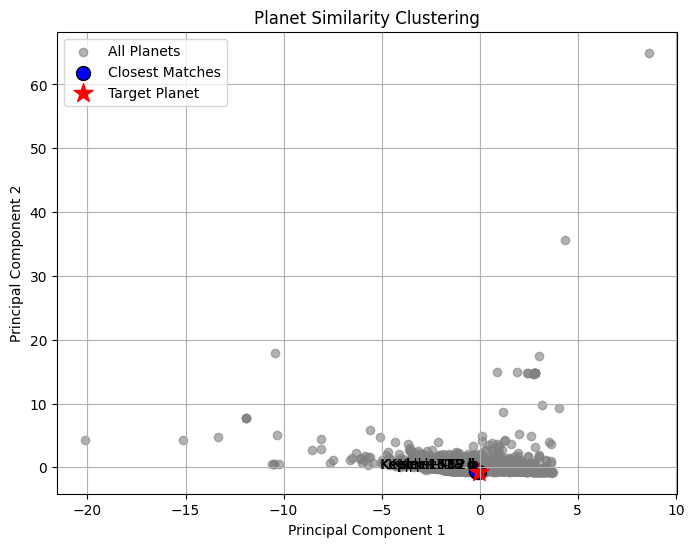

In [255]:
# Perform PCA for visualization (reduce to 2D)
pca = PCA(n_components=2)
data_pca = pca.fit_transform(df_imputed)
new_row_pca = pca.transform(earth_imputed)

# Convert to DataFrame for easier plotting
df_pca = pd.DataFrame(data_pca, index=df.index, columns=['PC1', 'PC2'])

# Plot all planets
plt.figure(figsize=(8, 6))
plt.scatter(df_pca['PC1'], df_pca['PC2'], c='gray', label='All Planets', alpha=0.6)

# Highlight the 5 closest planets
df_pca_closest = df_pca.loc[closest_planets]
plt.scatter(df_pca_closest['PC1'], df_pca_closest['PC2'], c='blue', label='Closest Matches', s=100, edgecolors='black')

# Highlight the target planet
plt.scatter(new_row_pca[:, 0], new_row_pca[:, 1], c='red', marker='*', s=200, label='Target Planet')

# Annotate planet names
for planet, (x, y) in df_pca_closest.iterrows():
    plt.text(x, y, planet, fontsize=10, verticalalignment='bottom', horizontalalignment='right')

# Set labels and title
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Planet Similarity Clustering')
plt.legend()
plt.grid()
plt.show()

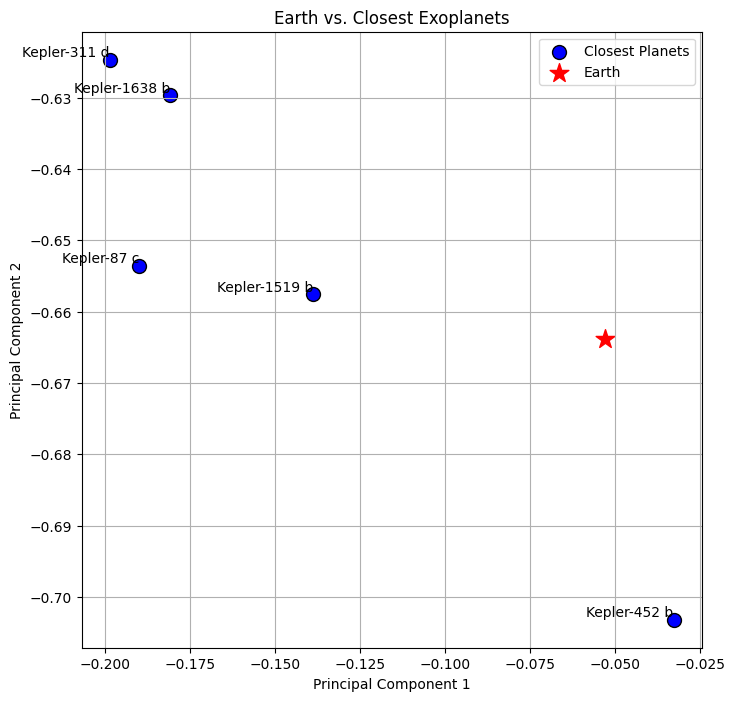

In [257]:
# Perform PCA for visualization (reduce to 2D)
pca = PCA(n_components=2)
all_data = np.vstack([df_imputed, earth_imputed])  # Combine data + Earth for PCA
data_pca = pca.fit_transform(all_data)

# Convert to DataFrame
df_pca = pd.DataFrame(data_pca[:-1], index=df.index, columns=['PC1', 'PC2'])  # All planets
earth_pca = data_pca[-1]  # Earth's coordinates

# Filter to only include Earth and the 5 closest planets
df_pca_closest = df_pca.loc[closest_planets]

# Create the scatter plot
plt.figure(figsize=(8, 8))

# Plot only the closest planets
plt.scatter(df_pca_closest['PC1'], df_pca_closest['PC2'], c='blue', label='Closest Planets', s=100, edgecolors='black')

# Highlight Earth
plt.scatter(earth_pca[0], earth_pca[1], c='red', marker='*', s=200, label='Earth')

# Annotate planet names
for planet, (x, y) in df_pca_closest.iterrows():
    plt.text(x, y, planet, fontsize=10, verticalalignment='bottom', horizontalalignment='right')

# Set labels and title
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Earth vs. Closest Exoplanets')
plt.legend()
plt.grid()
plt.show()